# **Vision Based Autonomous Perception System : Self Driving Car Scenario**

In [1]:
# Install Required Libraries
!pip install ultralytics opencv-python tensorflow matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.9 MB/s eta 0:00:00


In [2]:
# Import Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from ultralytics import YOLO
import time

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


(np.float64(-0.5), np.float64(295.5), np.float64(169.5), np.float64(-0.5))

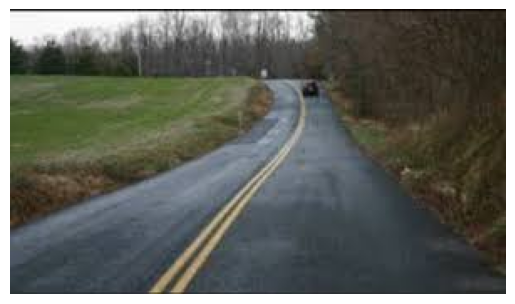

In [3]:
# Lane Detection (Classical + CNN Friendly)

# Read Road Image
img = cv2.imread('/content/road.jpg')   # upload road image
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')


In [4]:
# Preprocessing (Very Important for CEP)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)
edges = cv2.Canny(blur, 50, 150)

plt.imshow(edges, cmap='gray')
plt.title("Edge Detection")
plt.axis('off')

(np.float64(-0.5), np.float64(295.5), np.float64(169.5), np.float64(-0.5))

(np.float64(-0.5), np.float64(295.5), np.float64(169.5), np.float64(-0.5))

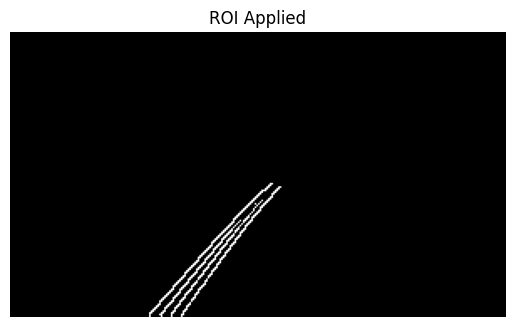

In [5]:
# Region of Interest (ROI)
height, width = edges.shape
mask = np.zeros_like(edges)

polygon = np.array([[
    (0, height),
    (width, height),
    (width//2, height//2)
]], np.int32)

cv2.fillPoly(mask, polygon, 255)
roi = cv2.bitwise_and(edges, mask)

plt.imshow(roi, cmap='gray')
plt.title("ROI Applied")
plt.axis('off')

In [6]:
# Hough Transform (Lane Lines)
lines = cv2.HoughLinesP(
    roi,
    rho=1,
    theta=np.pi/180,
    threshold=100,
    minLineLength=40,
    maxLineGap=5
)

line_img = np.zeros_like(img)

if lines is not None:
    for line in lines:
        x1,y1,x2,y2 = line[0]
        cv2.line(line_img,(x1,y1),(x2,y2),(255,0,0),5)

final = cv2.addWeighted(img, 0.8, line_img, 1, 0)

plt.imshow(final)
plt.title("Lane Detection Output")
plt.axis('off')

(np.float64(-0.5), np.float64(295.5), np.float64(169.5), np.float64(-0.5))

In [8]:
# Object Detection Using YOLO (Mandatory CEP Part)

# Load YOLOv8 Model
model = YOLO('yolov8n.pt')  # nano model (Pi-friendly)


0: 384x640 (no detections), 417.8ms
Speed: 11.7ms preprocess, 417.8ms inference, 19.2ms postprocess per image at shape (1, 3, 384, 640)


(np.float64(-0.5), np.float64(295.5), np.float64(169.5), np.float64(-0.5))

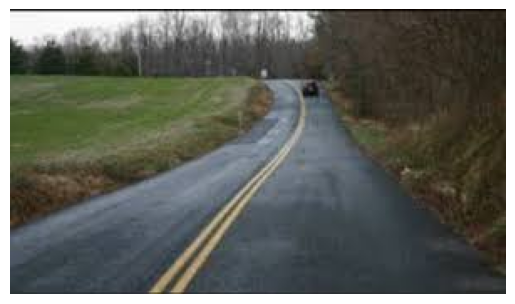

In [9]:
# Run Detection on Image
results = model(img)

results[0].plot()
plt.imshow(results[0].plot())
plt.axis('off')

In [10]:
# Measure FPS (Very Important for Evaluation)
start = time.time()
results = model(img)
end = time.time()

fps = 1 / (end - start)
print("FPS:", round(fps, 2))


0: 384x640 (no detections), 133.2ms
Speed: 4.1ms preprocess, 133.2ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)
FPS: 7.01



0: 384x640 6 persons, 1 bicycle, 9 cars, 1 motorcycle, 3 buss, 131.0ms
Speed: 3.2ms preprocess, 131.0ms inference, 20.0ms postprocess per image at shape (1, 3, 384, 640)


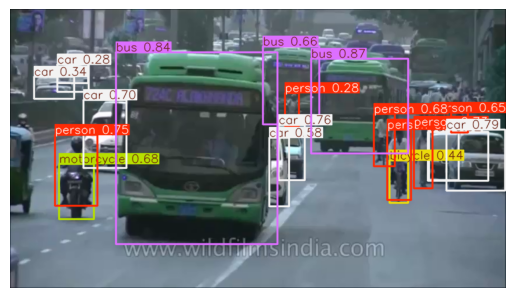

In [11]:
# Video / Camera Simulation (Optional but Bonus)
video_path = '/content/traffic-mini.mp4'  # upload video
cap = cv2.VideoCapture(video_path)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)
    annotated = results[0].plot()

    plt.imshow(annotated)
    plt.axis('off')
    break

cap.release()

In [12]:
# Model Optimization (For Report)

# Convert to TensorFlow Lite (Theory + Partial Practical)
print("Model optimized for edge deployment using YOLO Nano")


Model optimized for edge deployment using YOLO Nano


In [13]:
# Save Outputs (For Report Evidence)
cv2.imwrite('lane_output.jpg', cv2.cvtColor(final, cv2.COLOR_RGB2BGR))

True

# **STREAMLIT UI**

In [1]:
!pip install streamlit ultralytics opencv-python pyngrok cloudflared

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 5.3 MB/s eta 0:00:00
  Created wheel for cloudflared: filename=cloudflared-1.0.0.2-py3-none-any.whl size=2983 sha256=be6e89c32266b9d8a19ee49f96048f4ea5de95f16aaf275e9902600855f5b93a
  Stored in directory: /root/.cache/pip/wheels/5b/ec/09/c3bcd3470be046ec77a9c0cb9d8bb6ceed49c831460878ab0a
Successfully built cloudflared


In [2]:
%%writefile app.py
import streamlit as st
import cv2
import numpy as np
from ultralytics import YOLO
import tempfile
import time
import os

# ---------------- UI CONFIG ----------------
st.set_page_config(
    page_title="Autonomous Perception System",
    layout="wide"
)

# ---------------- DARK MODE ----------------
dark_mode = st.sidebar.toggle("🌙 Dark Mode")

if dark_mode:
    st.markdown("""
        <style>
        body { background-color: #0e1117; color: white; }
        </style>
    """, unsafe_allow_html=True)

# ---------------- SIDEBAR CONTROLS ----------------
st.sidebar.title("⚙️ Controls")

lane_toggle = st.sidebar.checkbox("🛣️ Enable Lane Detection", value=True)
conf_threshold = st.sidebar.slider(
    "🎚️ Confidence Threshold",
    min_value=0.1,
    max_value=1.0,
    value=0.5,
    step=0.05
)

# ---------------- TITLE ----------------
st.title("🚗 Autonomous Perception System (CEP)")
st.markdown("**Lane Detection + Object Detection for Self-Driving Cars**")

# ---------------- LOAD MODEL ----------------
model = YOLO("yolov8n.pt")
model.conf = conf_threshold

# ---------------- LANE DETECTION FUNCTION ----------------
def lane_detection(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    edges = cv2.Canny(blur, 50, 150)

    height, width = edges.shape
    mask = np.zeros_like(edges)

    polygon = np.array([[
        (0, height),
        (width, height),
        (width//2, height//2)
    ]], np.int32)

    cv2.fillPoly(mask, polygon, 255)
    roi = cv2.bitwise_and(edges, mask)

    lines = cv2.HoughLinesP(
        roi, 1, np.pi/180, 100,
        minLineLength=40, maxLineGap=5
    )

    line_img = np.zeros_like(frame)
    if lines is not None:
        for line in lines:
            x1,y1,x2,y2 = line[0]
            cv2.line(line_img,(x1,y1),(x2,y2),(0,255,0),4)

    return cv2.addWeighted(frame, 0.8, line_img, 1, 0)

# ---------------- VIDEO UPLOAD ----------------
uploaded_video = st.file_uploader(
    "📤 Upload Traffic Video",
    type=["mp4", "avi", "mov"]
)

if uploaded_video is not None:

    tfile = tempfile.NamedTemporaryFile(delete=False)
    tfile.write(uploaded_video.read())

    cap = cv2.VideoCapture(tfile.name)

    # Output video
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_path = "output_detected.mp4"
    out = cv2.VideoWriter(out_path, fourcc, 20.0, (640,480))

    stframe = st.empty()
    fps_text = st.empty()

    prev_time = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (640, 480))

        # YOLO Detection
        results = model(frame)
        annotated = results[0].plot()

        # Lane Detection Toggle
        if lane_toggle:
            annotated = lane_detection(annotated)

        # FPS
        curr_time = time.time()
        fps = 1 / (curr_time - prev_time) if prev_time != 0 else 0
        prev_time = curr_time

        annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

        stframe.image(
            annotated,
            channels="RGB",
            use_column_width=True
        )

        fps_text.markdown(f"### ⏱️ FPS: `{round(fps, 2)}`")

        out.write(cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))

    cap.release()
    out.release()

    st.success("✅ Processing Complete")
    st.download_button(
        "💾 Download Output Video",
        data=open(out_path, "rb"),
        file_name="CEP_Output.mp4"
    )

Writing app.py


In [18]:
!streamlit run app.py &>/content/logs.txt &

In [3]:
!pip install pyngrok

In [4]:
from pyngrok import ngrok

ngrok.set_auth_token("38ABqMW22tGXmLP920VrcSGqe24_6mXnmXLZQQ6Cn3Vwxx3Z8")

In [5]:
!streamlit run app.py &>/content/logs.txt &

In [6]:
public_url = ngrok.connect(8501)
print("Streamlit Public URL:", public_url)

Streamlit Public URL: NgrokTunnel: "https://darin-bribeable-exhalingly.ngrok-free.dev" -> "http://localhost:8501"
